# Intraday Volume Profile — the typical shape across all days

Recreates the single-day 15-minute bar chart across **all ~197 days**: per 15-min time-of-day bucket, the **median** and **mean** across days of (a) shares traded and (b) number of trades — market-wide (all 38 shortlist names pooled), continuous phase only, market=REG only.

Because Friday and Ramadan sessions have different bells, mixing them would smear the close ramp across clock times. So the profile is built **per session type** — the regular Mon–Thu profile (~147 days) is the headline; Friday/Ramadan shown after.

**Purpose:** decide the bucket-count question — if the close ramp starts ~45 min out, a 4th bucket (Pre-close-30) is justified; if it's confined to the last ~15 min, the 3-bucket model already captures it. All heavy lifting in DuckDB. Run All.

In [1]:
# ---- imports + paths ----
import duckdb
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

# parsed store (Hive-partitioned: trades/date=YYYY-MM-DD/*.parquet)
PARSED = '/Users/shazzak/Capital Stake - Parsed'
RESULTS = Path('/Users/shazzak/Capital Stake - Results')
WATCHLIST = RESULTS / 'mm_watchlist_final.csv'

# the session-segments table (from build_volume_profile.py): date -> type + segments
seg = pd.read_csv(sorted(RESULTS.glob('session_segments_*.csv'))[-1])
print('session types available:'); print(seg.session_type.value_counts().to_string())
# shortlist symbols as a SQL list
syms = pd.read_csv(WATCHLIST)['symbol'].tolist()
SYM_LIST = ','.join(f"'{s}'" for s in syms)
con = duckdb.connect()

session types available:
session_type
reg        147
reg-f       36
ram-reg     20
ram-f        4


In [2]:
# ---- the one heavy query: per (date, 15-min bucket): shares + trade count ----
# Continuous-phase filtering is done via the per-date segments (start/end ms of
# each continuous interval) -- we pass them in as a VALUES table and join.
# Build the segments VALUES rows: (date, seg_start_ms, seg_end_ms)
seg_rows = []
for _, r in seg.iterrows():
    for p in r['segments'].split(';'):
        s, e = p.split(':')
        seg_rows.append((r['date'], int(s), int(e), r['session_type']))
seg_sql = ','.join(f"('{d}',{s},{e},'{t}')" for d, s, e, t in seg_rows)

# per-day per-bucket aggregates, continuous-phase + REG only, shortlist only.
# epoch_ms(transact_time) gives exchange ms; bucket = 15-min floor of time-of-day.
q = f"""
WITH segs(d, s_ms, e_ms, stype) AS (VALUES {seg_sql}),
t AS (
    SELECT regexp_extract(filename, 'date=([0-9-]+)', 1) AS d,
           epoch_ms(transact_time) AS ts,
           qty
    FROM read_parquet('{PARSED}/trades/date=*/*.parquet', filename=true)
    WHERE symbol IN ({SYM_LIST}) AND market = 'REG' AND qty > 0
)
SELECT t.d,
       any_value(segs.stype) AS stype,
       -- 15-minute bucket label as minutes-of-day (PKT = UTC+5)
       CAST(FLOOR(((t.ts + 5*3600*1000) % 86400000) / 900000) AS INT) AS bucket15,
       SUM(t.qty)  AS shares,
       COUNT(*)    AS n_trades
FROM t JOIN segs ON t.d = segs.d AND t.ts BETWEEN segs.s_ms AND segs.e_ms
GROUP BY t.d, bucket15
ORDER BY t.d, bucket15
"""
day_buckets = con.execute(q).df()
print(f'{len(day_buckets):,} (date, bucket) rows across {day_buckets.d.nunique()} days')

4,606 (date, bucket) rows across 207 days


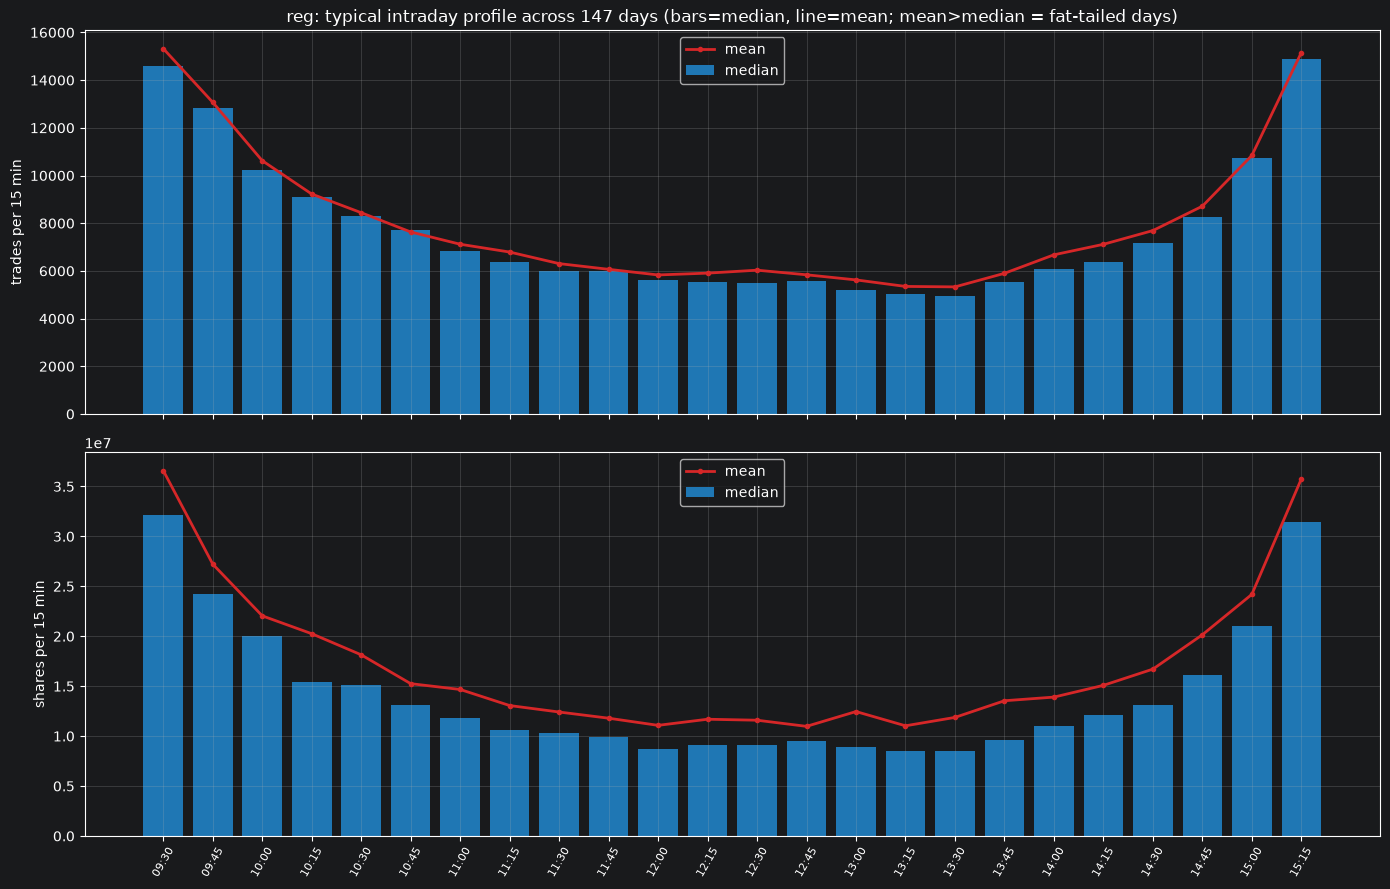

In [3]:
# ---- the typical-day profile per session type: median + mean across days ----
# bucket15 -> clock label (bucket * 15 min from midnight PKT)
def label(b):
    m = int(b) * 15
    return f'{m//60:02d}:{m%60:02d}'

def profile(stype):
    # this session type's day-bucket rows
    x = day_buckets[day_buckets.stype == stype]
    # median and mean ACROSS DAYS per bucket, for both measures
    g = x.groupby('bucket15').agg(
        med_shares=('shares', 'median'), avg_shares=('shares', 'mean'),
        med_trades=('n_trades', 'median'), avg_trades=('n_trades', 'mean'),
        days=('d', 'nunique')).reset_index()
    # drop buckets present on only a few days (session-edge stragglers)
    g = g[g.days >= x.d.nunique() * 0.5]
    g['clock'] = g.bucket15.map(label)
    return g

def draw(stype):
    g = profile(stype)
    if len(g) == 0:
        print(f'no data for {stype}'); return
    n_days = day_buckets[day_buckets.stype == stype].d.nunique()
    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
    # TOP: number of trades (matches your original top chart)
    axes[0].bar(g.clock, g.med_trades, color='#1f77b4', label='median')
    axes[0].plot(g.clock, g.avg_trades, color='#d62728', lw=2, marker='o', ms=3,
                 label='mean')
    axes[0].set_ylabel('trades per 15 min')
    axes[0].set_title(f'{stype}: typical intraday profile across {n_days} days '
                      f'(bars=median, line=mean; mean>median = fat-tailed days)')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    # BOTTOM: shares traded (matches your original bottom chart)
    axes[1].bar(g.clock, g.med_shares, color='#1f77b4', label='median')
    axes[1].plot(g.clock, g.avg_shares, color='#d62728', lw=2, marker='o', ms=3,
                 label='mean')
    axes[1].set_ylabel('shares per 15 min')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[1].tick_params(axis='x', rotation=60, labelsize=8)
    plt.tight_layout(); plt.show()
    return g

# the headline: regular Mon-Thu days
g_reg = draw('reg')

In [4]:
# ---- the bucket-count decision, quantified (reg days) ----
# normalise the median-shares profile vs the MIDDLE-of-day baseline, and show
# each bucket's multiple of that baseline for the final 90 minutes.
g = g_reg.reset_index(drop=True)
# baseline = median of the middle third of buckets (away from open and close)
n = len(g)
base = g.iloc[n//3:2*n//3]['med_shares'].median()
print(f'midday baseline: {base:,.0f} shares / 15min\n')
print('final 90 minutes, each bucket as a multiple of the midday baseline:')
tail = g.tail(6)
for _, r in tail.iterrows():
    mult = r.med_shares / base
    bar = '#' * int(round(mult * 4))
    print(f"  {r.clock}  {r.med_shares:>12,.0f}  {mult:4.1f}x  {bar}")
print('\nREAD: if only the LAST bucket is well above ~1.3x, the 3-bucket model')
print('already captures the ramp. If the 45-60min-out buckets are ALSO clearly')
print('elevated (>=1.3x), a 4th bucket (Pre-close-30: minutes 45->15) is justified')
print('and the unwind model is currently valuing that zone too low.')

midday baseline: 9,130,248 shares / 15min

final 90 minutes, each bucket as a multiple of the midday baseline:
  14:00    10,993,059   1.2x  #####
  14:15    12,120,012   1.3x  #####
  14:30    13,149,187   1.4x  ######
  14:45    16,078,545   1.8x  #######
  15:00    21,065,175   2.3x  #########
  15:15    31,479,784   3.4x  ##############

READ: if only the LAST bucket is well above ~1.3x, the 3-bucket model
already captures the ramp. If the 45-60min-out buckets are ALSO clearly
elevated (>=1.3x), a 4th bucket (Pre-close-30: minutes 45->15) is justified
and the unwind model is currently valuing that zone too low.


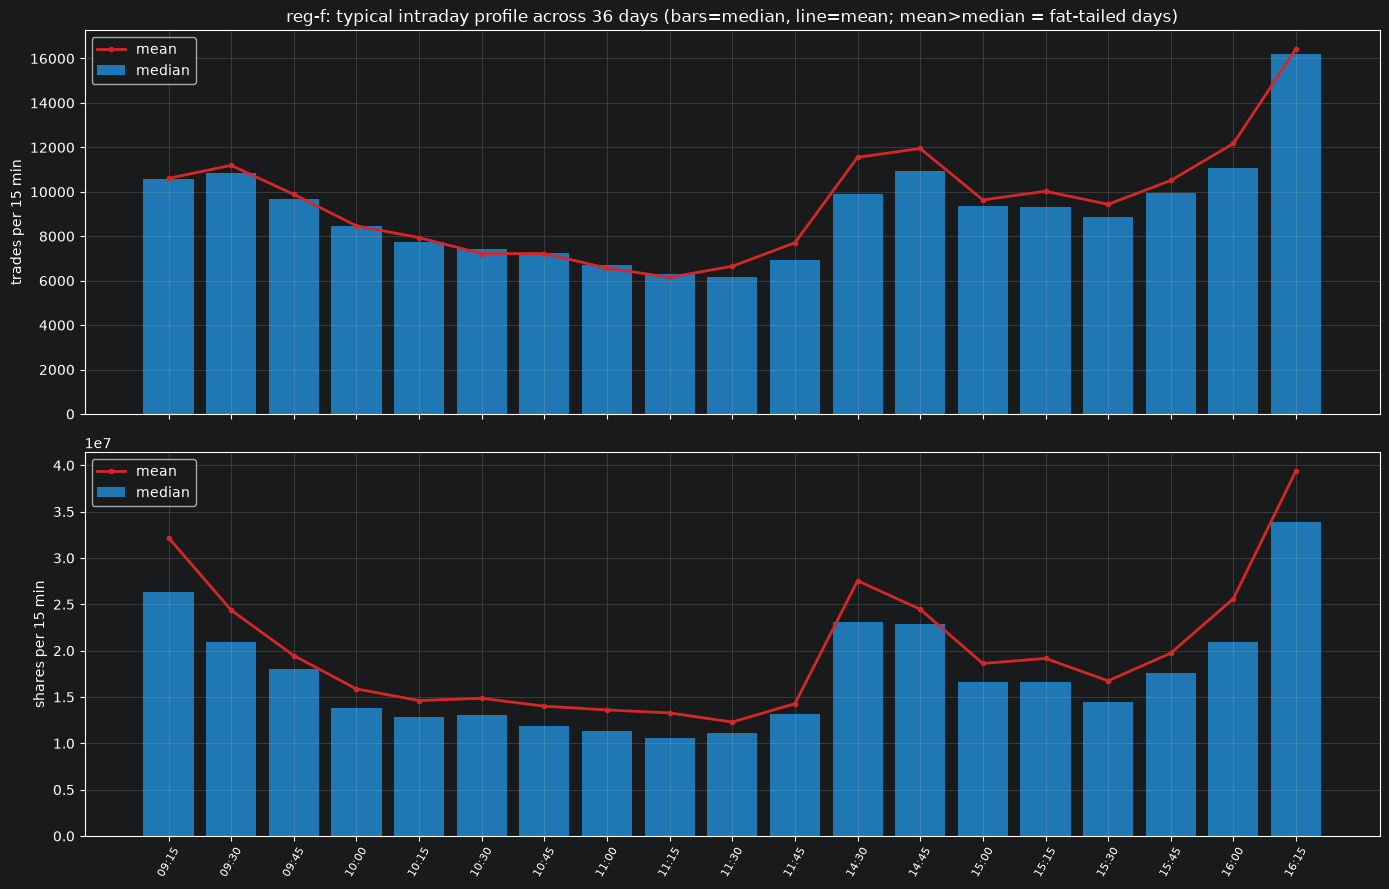

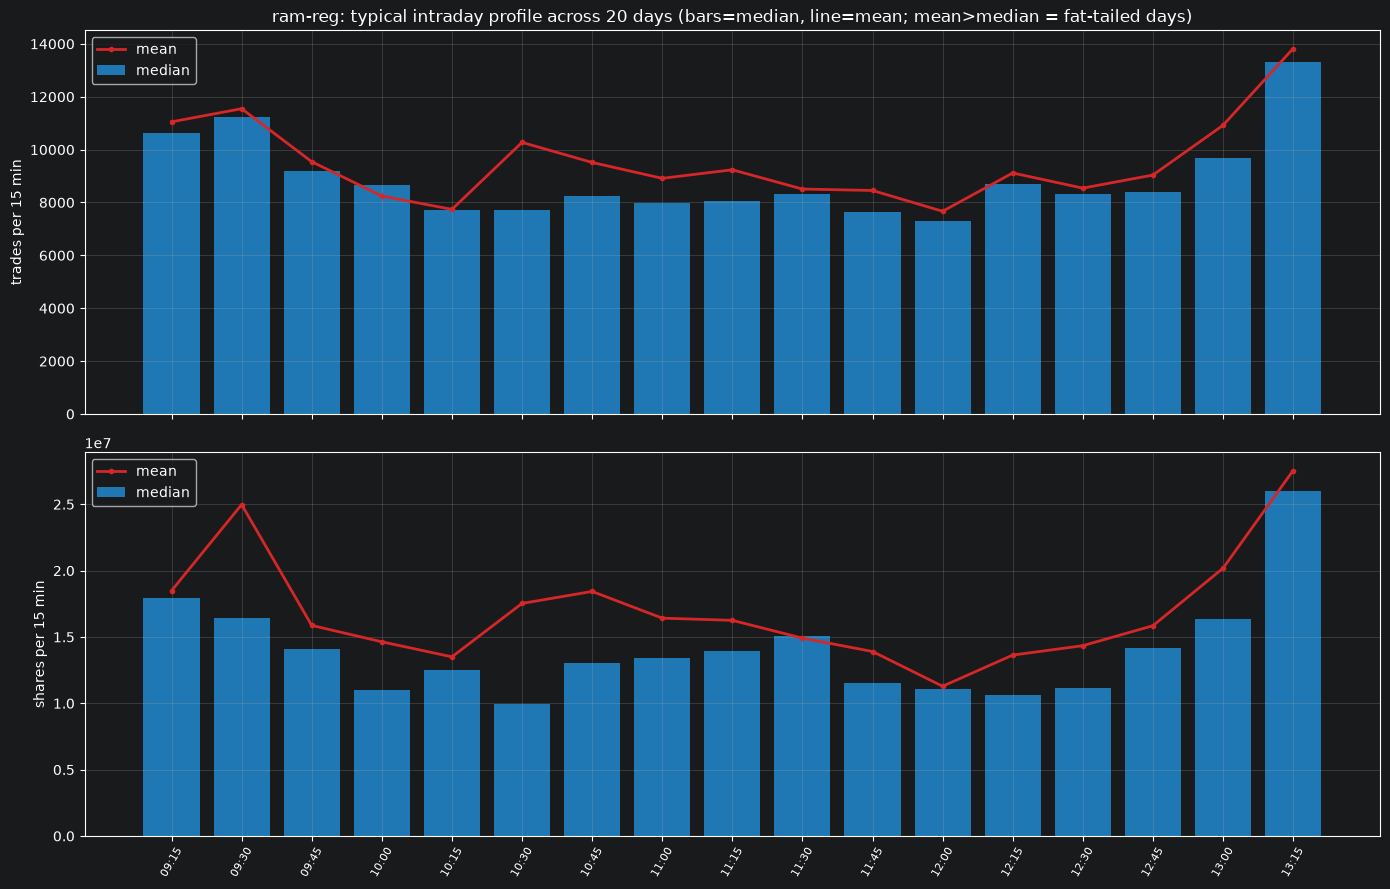

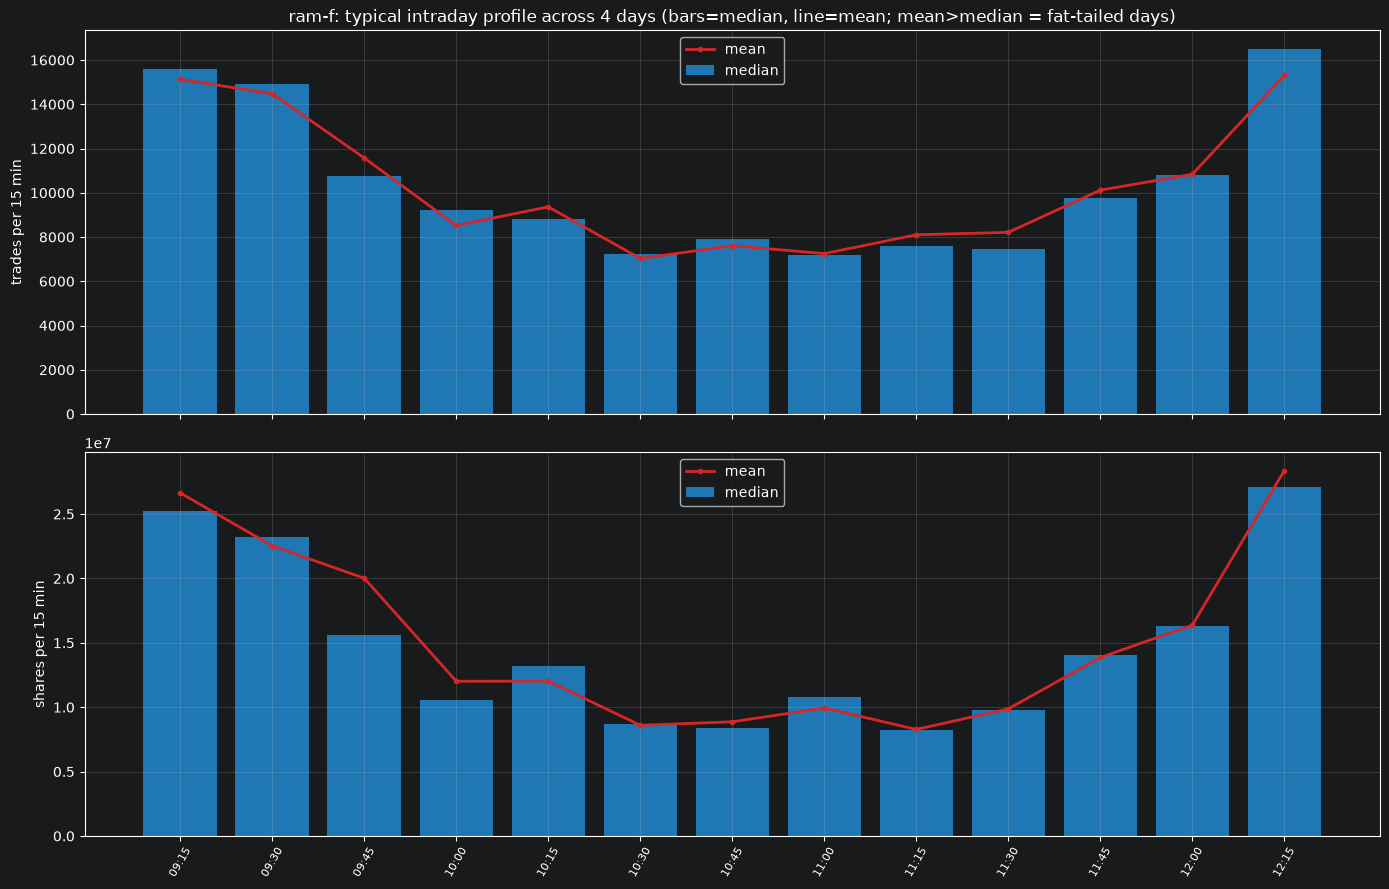

In [5]:
# ---- the other session types, for completeness ----
for st in ['reg-f', 'ram-reg', 'ram-f']:
    draw(st)

### Notes

- **Median vs mean gap**: the red mean line sitting far above the blue median bars in a bucket means a few extreme days dominate that time-of-day (halts/reopens, index events). The unwind model uses medians for exactly this reason.
- **Friday (reg-f)** shows the Jumu'ah gap: buckets vanish between the morning and afternoon segments — both segments have their own mini close-ramp into the break/close.
- The profile here is **market-wide** (38 names pooled), matching the chart being recreated; the per-name version (what the unwind actually uses) is in `volume_profile_*.csv`.